# IP-Adapter

In [33]:
import torch
# from diffusers import AutoPipelineForImage2Image

from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionImg2ImgPipeline,
    StableDiffusionInpaintPipelineLegacy,
    StableDiffusionXLImg2ImgPipeline,
    DDIMScheduler,
    AutoencoderKL,
)

from transformers import CLIPVisionModelWithProjection

from PIL import Image
# from ip_adapter import IPAdapterPlus

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

print(f"device: {device}")

device: mps


In [12]:
vae_model_path = "stabilityai/sd-vae-ft-mse"
vae = AutoencoderKL.from_pretrained(vae_model_path).to(dtype=torch.float16)

/Users/hhung/miniconda3/envs/transformer/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [13]:
def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size
    
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

noise_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear",
    clip_sample=False,
    set_alpha_to_one=False,
    steps_offset=1,
)

In [34]:
image_encoder = CLIPVisionModelWithProjection.from_pretrained(
    "h94/IP-Adapter", 
    subfolder="models/image_encoder",
    torch_dtype=torch.float16
).to(device)

pipeline = StableDiffusionXLImg2ImgPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    image_encoder=image_encoder,
    torch_dtype=torch.float16
).to(device)

# pipeline = AutoPipelineForImage2Image.from_pretrained(
#  "stabilityai/stable-diffusion-xl-base-1.0",
#  torch_dtype=torch.float16
# ).to(device)

pipeline.load_ip_adapter("h94/IP-Adapter",
                        subfolder="sdxl_models",
                        weight_name="ip-adapter-plus_sdxl_vit-h.bin")

# load SD pipeline

# base_model_path = "SG161222/Realistic_Vision_V4.0_noVAE"

# pipe = StableDiffusionPipeline.from_pretrained(
#     base_model_path,
#     torch_dtype=torch.float16,
#     scheduler=noise_scheduler,
#     vae=vae,
#     feature_extractor=None,
#     safety_checker=None
# )

Loading weights: 100%|███████████████████████████████████████████████████████████████████████| 520/520 [00:00<00:00, 4127.11it/s]
CLIPVisionModelWithProjection LOAD REPORT from: h94/IP-Adapter
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████████████████████████████████████████████████████████| 7/7 [00:13<00:00,  1.99s/it]


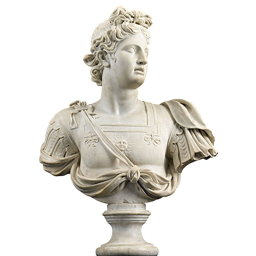

In [36]:
from IPython.display import display

image = Image.open("./statue.png").convert("RGB")

# image.resize((256, 256)).show()
display(image.resize((256, 256)))

image_embeds = pipeline.prepare_ip_adapter_image_embeds(
   ip_adapter_image=image,
   ip_adapter_image_embeds=None,
   device=device,
   num_images_per_prompt=1,
   do_classifier_free_guidance=True,
)

torch.save(image_embeds, "image_embeds.ipadpt")

# load ip-adapter

# image_encoder_path = "models/image_encoder" 
# ip_ckpt = "models/ip-adapter-plus_sd15.bin"

# ip_model = IPAdapterPlus(pipe, image_encoder_path, ip_ckpt, device, num_tokens=16)

100%|████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [02:38<00:00,  4.28s/it]


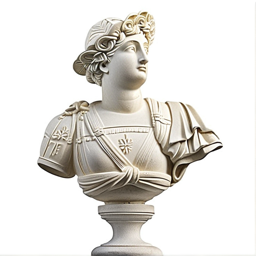

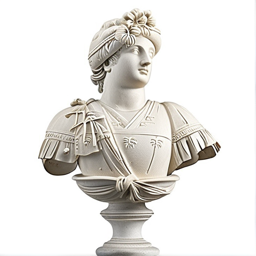

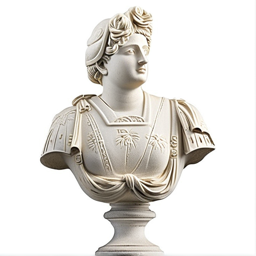

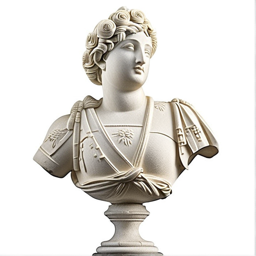

In [41]:
# pipeline.set_ip_adapter_scale(0.6)
# image_embeds = torch.load("image_embeds.ipadpt")

# output_img = pipeline(
#    prompt="best quality, high quality, wearing a hat on the beach",
#    image=image,
#    ip_adapter_image_embeds=image_embeds,
#    negative_prompt="deformed, ugly, low res, bad anatomy, worst quality",
#    num_inference_steps=100,
#    num_samples=4, 
#    generator=torch.Generator(device=device).manual_seed(42),
# ).images


output_img = pipeline(
    prompt="a stone statue wearing a distinct straw hat, sitting on a tropical beach, white sand, palm trees, 8k resolution, highly detailed",
    image=image,
    strength=0.75, 
    ip_adapter_image_embeds=image_embeds,
    negative_prompt="deformed, ugly, low res, bad anatomy, worst quality",
    num_inference_steps=50,
    guidance_scale=7.5,      # Standard CFG
    # Change num_samples to num_images_per_prompt
    num_images_per_prompt=4, 
    generator=torch.Generator(device=device).manual_seed(42),
).images


for img in output_img:
    # img.show()
    display(img.resize((256, 256)))


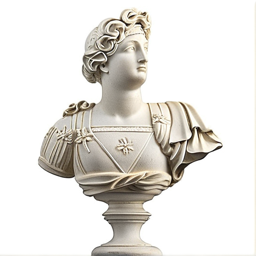

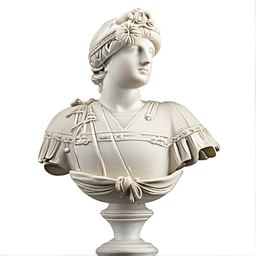

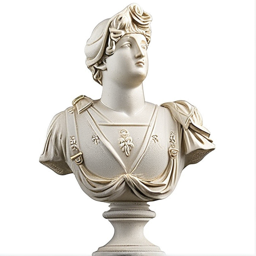

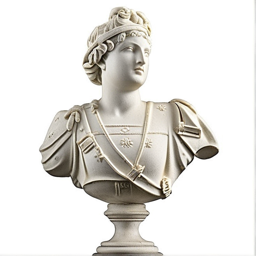

In [38]:
for img in output_img:
    # img.show()
    display(img.resize((256, 256)))

In [39]:
output_img = pipeline(
    prompt="a statue wearing a straw hat on a beach",
    image=image,
    strength=0.7, 
    ip_adapter_image_embeds=image_embeds,
    negative_prompt="deformed, ugly, low res, bad anatomy, worst quality",
    num_inference_steps=50,
    # Change num_samples to num_images_per_prompt
    num_images_per_prompt=4, 
    generator=torch.Generator(device=device).manual_seed(42),
).images

100%|████████████████████████████████████████████████████████████████████████████████████████████| 35/35 [02:30<00:00,  4.30s/it]


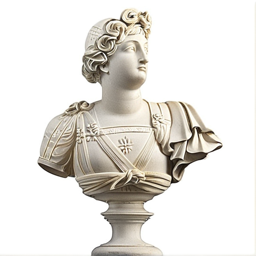

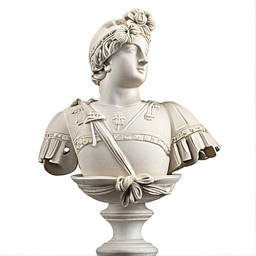

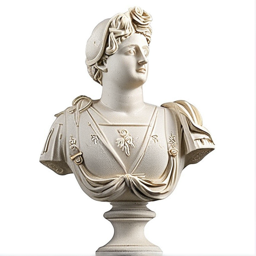

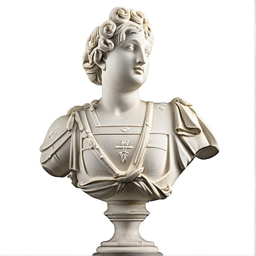

In [40]:
for img in output_img:
    # img.show()
    display(img.resize((256, 256)))